In [1]:
!/usr/bin/time -v bash -c './reference_step1.sh'

	Command being timed: "bash -c ./reference_step1.sh"
	User time (seconds): 15.89
	System time (seconds): 0.14
	Percent of CPU this job got: 99%
	Elapsed (wall clock) time (h:mm:ss or m:ss): 0:16.04
	Average shared text size (kbytes): 0
	Average unshared data size (kbytes): 0
	Average stack size (kbytes): 0
	Average total size (kbytes): 0
	Maximum resident set size (kbytes): 34332
	Average resident set size (kbytes): 0
	Major (requiring I/O) page faults: 0
	Minor (reclaiming a frame) page faults: 15882
	Voluntary context switches: 11
	Involuntary context switches: 82
	Swaps: 0
	File system inputs: 0
	File system outputs: 1680
	Socket messages sent: 0
	Socket messages received: 0
	Signals delivered: 0
	Page size (bytes): 4096
	Exit status: 0


In [2]:
!which python

/home/z.ma/miniconda3/envs/bioinfo/bin/python


In [3]:
!/usr/bin/time -v bash -c 'python admixture_em.py \
    --input_prefix data_and_results/step1/intermediate/step1_admixture.pruned \
    --output_folder data_and_results/step1/results_em \
    --k_values 3 \
    --max_iters 1000 \
    --early_stop_rate 2e-6 \
    --random_seed 42 \
    --min_prob 1e-6 \
    '

Genotype summary:
Samples: 462 SNPs: 26472
439.0 461.9306436990027 462.0
Initial F summary:
0.5 0.8933573707861626 0.9899777282850779
0.47123174406680135 0.8933423113983443 1.0310314129389602
	Command being timed: "bash -c python admixture_em.py      --input_prefix data_and_results/step1/intermediate/step1_admixture.pruned      --output_folder data_and_results/step1/results_em      --k_values 3      --max_iters 1000      --early_stop_rate 2e-6      --random_seed 42      --min_prob 1e-6      "
	User time (seconds): 9218.32
	System time (seconds): 989.23
	Percent of CPU this job got: 2569%
	Elapsed (wall clock) time (h:mm:ss or m:ss): 6:37.23
	Average shared text size (kbytes): 0
	Average unshared data size (kbytes): 0
	Average stack size (kbytes): 0
	Average total size (kbytes): 0
	Maximum resident set size (kbytes): 1204944
	Average resident set size (kbytes): 0
	Major (requiring I/O) page faults: 1
	Minor (reclaiming a frame) page faults: 10571969
	Voluntary context switches: 104624
	

In [4]:
!/usr/bin/time -v bash -c 'python admixture_squarem.py \
    --input_prefix data_and_results/step1/intermediate/step1_admixture.pruned \
    --output_folder data_and_results/step1/results_squarem \
    --k_values 3 \
    --max_iters 1000 \
    --early_stop_rate 2e-6 \
    --random_seed 42 \
    --min_prob 1e-6 \
    --squarem_step_max 15.0 \
    '

Genotype summary:
Samples: 462 SNPs: 26472
439.0 461.9306436990027 462.0
Initial F summary:
0.5 0.8933573707861626 0.9899777282850779
0.47123174406680135 0.8933423113983443 1.0310314129389602
	Command being timed: "bash -c python admixture_squarem.py      --input_prefix data_and_results/step1/intermediate/step1_admixture.pruned      --output_folder data_and_results/step1/results_squarem      --k_values 3      --max_iters 1000      --early_stop_rate 2e-6      --random_seed 42      --min_prob 1e-6      --squarem_step_max 15.0      "
	User time (seconds): 5445.52
	System time (seconds): 542.85
	Percent of CPU this job got: 4075%
	Elapsed (wall clock) time (h:mm:ss or m:ss): 2:26.91
	Average shared text size (kbytes): 0
	Average unshared data size (kbytes): 0
	Average stack size (kbytes): 0
	Average total size (kbytes): 0
	Maximum resident set size (kbytes): 1012044
	Average resident set size (kbytes): 0
	Major (requiring I/O) page faults: 2
	Minor (reclaiming a frame) page faults: 4742999

In [5]:
from plot_admixture import plot_admixture_results, compare_em_squarem

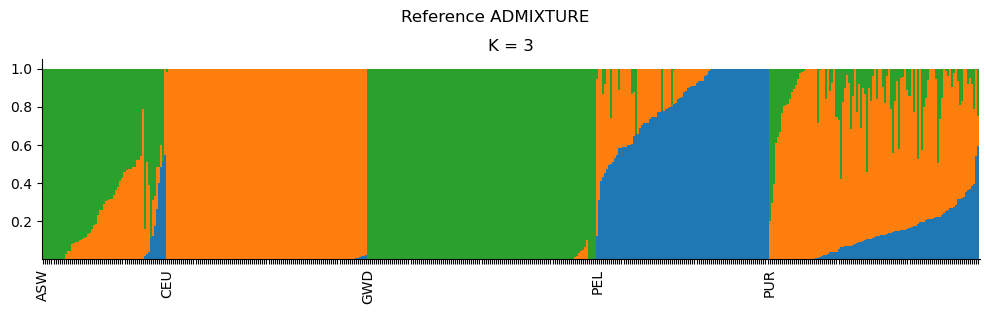

In [6]:
fig_reference = plot_admixture_results(
    fig_title = "Reference ADMIXTURE",
    sampleinfo_path = "data_and_results/step1/dataset/igsr_samples.tsv",
    fam_path = "data_and_results/step1/intermediate/step1_admixture.pruned.fam",
    sample_name = "Sample name",
    pop_code_name = "Population code",
    q_path_template = "data_and_results/step1/reference_results/step1_admixture.pruned.{K}.Q",
    k_values = [3],
)
fig_reference.show()

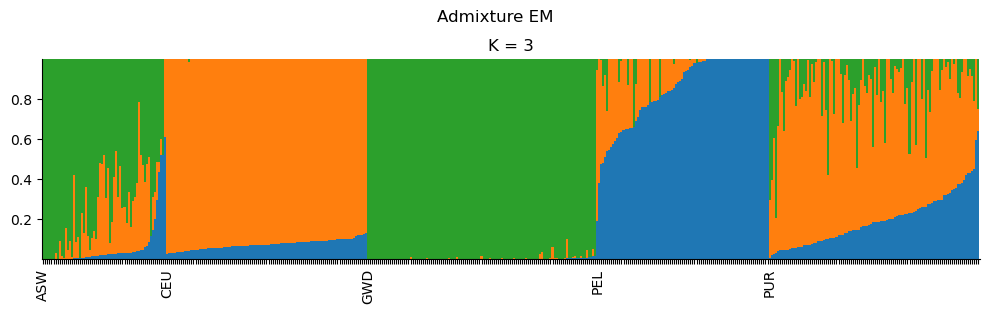

In [7]:
fig_em = plot_admixture_results(
    fig_title = "Admixture EM",
    sampleinfo_path = "data_and_results/step1/dataset/igsr_samples.tsv",
    fam_path = "data_and_results/step1/intermediate/step1_admixture.pruned.fam",
    sample_name = "Sample name",
    pop_code_name = "Population code",
    q_path_template = "data_and_results/step1/results_em/step1_admixture.pruned.{K}.Q",
    k_values = [3],
)
fig_em.show()

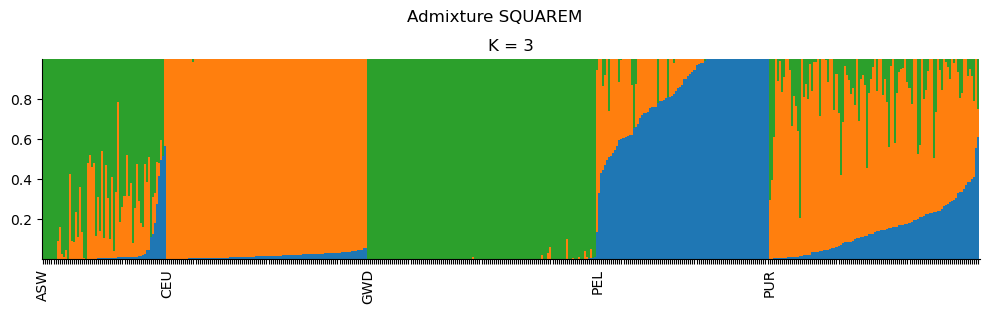

In [8]:
fig_em = plot_admixture_results(
    fig_title = "Admixture SQUAREM",
    sampleinfo_path = "data_and_results/step1/dataset/igsr_samples.tsv",
    fam_path = "data_and_results/step1/intermediate/step1_admixture.pruned.fam",
    sample_name = "Sample name",
    pop_code_name = "Population code",
    q_path_template = "data_and_results/step1/results_squarem/step1_admixture.pruned.{K}.Q",
    k_values = [3],
)
fig_em.show()

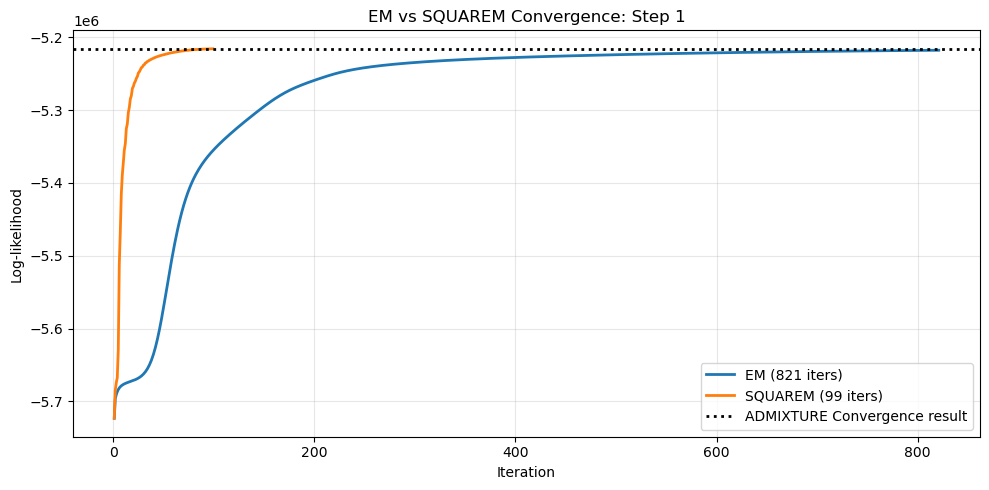

In [9]:
fig_compare = compare_em_squarem(
    fig_title = "EM vs SQUAREM Convergence: Step 1",
    em_npy_path = "data_and_results/step1/results_em/step1_admixture.pruned.3.npy",
    squarem_npy_path = "data_and_results/step1/results_squarem/step1_admixture.pruned.3.npy",
)
fig_compare.show()